# 1. General Information

In this Notebook, we will explore and analyze data related to Life Expectancy across different countries and years. The primary focus will be on understanding the factors that influence life expectancy using factors that are in the data. We will start by visualizing the data to identify trends and patterns. Following this, we will apply statistical and machine learning models to predict life expectancy based on various indicators.

The goals of this notebook are:

* Data Exploration and Visualization: To examine the dataset, understand its structure, and identify any significant correlations or trends.
* Data Preprocessing: To clean and prepare the data for modeling, addressing any missing values or inconsistencies.
* Modeling Life Expectancy: To build predictive models that estimate life expectancy based on the provided features.
* Evaluation and Interpretation: To assess the performance of the models and interpret the results, drawing meaningful insights that can help inform public health strategies and policies.

By the end of this analysis, I hope to gain a deeper understanding of the key determinants of life expectancy and how these factors vary across different regions and periods.

# 2. Information about the dataset.

In [402]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [403]:
data = pd.read_csv('Life Expectancy Data.csv.xls')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

As we see we have some null values in several features. Also we can see, that several columns have unnecessary spaces in their names. Antoher factor is that the names of the columns are not normalized - we will use snake case.

In [404]:
def snake_case(df_index: pd.Index) -> pd.Index:
    """
    Converts the column or index names from a Pandas DataFrame to snake_case format.

    This function replaces spaces in the names with underscores ("_") 
    and converts all characters to lowercase, following the snake_case naming convention.

    :param df_index: 
        The Pandas Index object, typically from `data.columns` or `data.index`, 
        representing the names to be transformed.
    :return: 
        A Pandas Index object with names converted to snake_case.
    """
    return df_index.str.strip().str.lower().str.replace(r'\s{1,2}', '_', regex=True)


In [405]:
data.columns = snake_case(data.columns)
data.head(2)

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness_1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0


# 3. Splitting the data

In this part, we will simply split the data in train / validation / test dataset. However, first, we will try to find a good feature to stratify the data. After this step, we will no longer look at the test set. Stratifying the data is important beacuse using simple `train_test_split` can give us non population like results. For instance we can have a lot of countries that are developed and just few countries that are still developing which can result in a highly biased model.

## 3.1 Checking the Status Variable

Lets check if `status` variable is good for statifying the data, by visualing it.

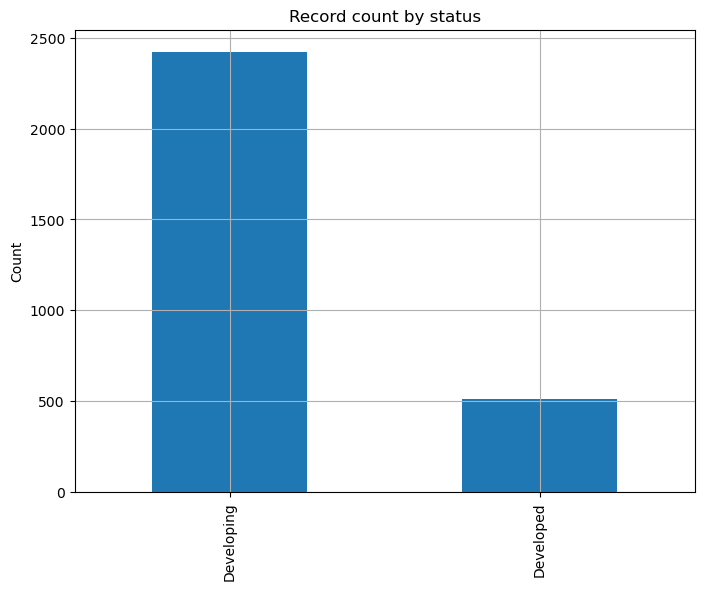

In [406]:
plt.figure(figsize=(8,6))
counts = data["status"].value_counts()
counts.plot(kind="bar");
plt.xlabel('');
plt.ylabel("Count");
plt.title("Record count by status");
plt.grid()

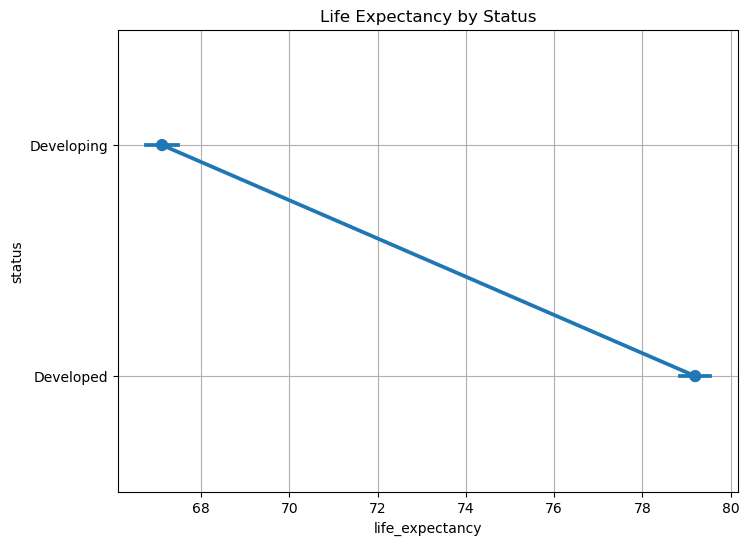

In [407]:
plt.figure(figsize=(8,6))
sns.pointplot(data, y="status", x="life_expectancy");
plt.title("Life Expectancy by Status");
plt.grid()

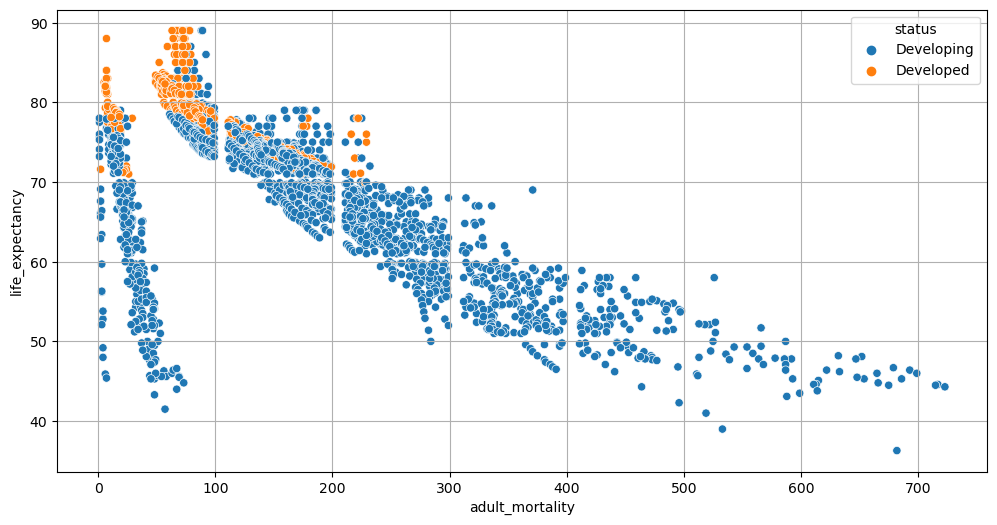

In [408]:
plt.figure(figsize=(12,6))
sns.scatterplot(data, x="adult_mortality",y="life_expectancy", hue="status")
plt.grid()

In [409]:
from scipy.stats import f_oneway
developing = data[data['status']=="Developing"]["life_expectancy"]
developed = data[data['status']=="Developed"]["life_expectancy"]
f_oneway(developed, developing, nan_policy = 'omit')

TypeError: f_oneway() got an unexpected keyword argument 'nan_policy'

Visualisation and Anova test shown us, that there's a big difference between counties that are developing and those caounties that are developed - which can be a good thing to stratify the data.

## 3.2 Checking the Country Variable

Based on the plot that is shown above we can see that Countries differs from one another. The biggest issue by stratifying the data by `status` is that, the model will not be trained for each country, beacause sample data will not take countries into consideration. For experimentation purposes we will create two datasets:

* One will be stratified by status
* One will be stratified by counties (that appear more than five times in the dataset)

For each of those datasets we will perform the same calculations, however for purpose of this notebook we will focus on analysing the data that will be stratified by `status`.

In [410]:
from sklearn.model_selection import train_test_split

countries = data["country"].value_counts()[data["country"].value_counts() > 5].index
data_country_split = data[data['country'].isin(countries)]

# Splitting by Country
train_data_country, temp_data_country = train_test_split(
    data_country_split,
    train_size=0.7,
    stratify=data_country_split['country']
)

val_data_country, test_data_country = train_test_split(
    temp_data_country,
    train_size=0.5, #50% per each sample
    stratify=temp_data_country['country']
)


# Splitting by Status

train_data_status, temp_data_status = train_test_split(
    data,
    train_size=0.7,
    stratify=data['status']
)

val_data_status, test_data_status = train_test_split(
    temp_data_status,
    train_size=0.5,
    stratify=temp_data_status['status']
)

In [411]:
data['status'].value_counts() / len(data) * 100

status
Developing    82.573179
Developed     17.426821
Name: count, dtype: float64

In [412]:
train_data_status['status'].value_counts() / len(train_data_status) * 100

status
Developing    82.587549
Developed     17.412451
Name: count, dtype: float64

In [413]:
val_data_status['status'].value_counts() / len(val_data_status) * 100

status
Developing    82.539683
Developed     17.460317
Name: count, dtype: float64

In [414]:
test_data_status['status'].value_counts() / len(test_data_status) * 100

status
Developing    82.539683
Developed     17.460317
Name: count, dtype: float64

# 4. Exploratory Data Analysis

In this part:

* Check the quality of the data,

* Clean the data,

* Search for valuable correlation between the features,

* Prepare the data for modelling by building dedicated pipelines.


## 4.1 Data Cleansing

As we know from the second chapter, we have some features with missing data. In this subchapter we will try to do someting about it to increase the quality of the data.

In [415]:
missing_value_cols = train_data_status.columns[train_data_status.isnull().any()].tolist()
train_data_status[missing_value_cols].describe()

,life_expectancy,adult_mortality,alcohol,hepatitis_b,bmi,polio,total_expenditure,diphtheria,gdp,population,thinness_1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
count,2049.000000,2049.000000,1921.000000,1666.000000,2035.000000,2042.000000,1897.000000,2042.000000,1745.000000,1.599000e+03,2035.000000,2035.000000,1941.000000,1944.000000
mean,69.156271,163.241093,4.567673,80.782113,38.117445,82.703722,5.962994,82.695397,7399.281630,1.366856e+07,4.987912,5.019902,0.623453,11.972788
std,9.534289,124.649029,4.044499,25.319175,19.955155,23.088689,2.500561,23.089334,14237.215225,7.069327e+07,4.516914,4.615136,0.214253,3.377727
min,41.000000,1.000000,0.010000,1.000000,1.000000,3.000000,0.650000,2.000000,5.668726,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,62.900000,72.000000,0.800000,77.000000,19.400000,78.000000,4.260000,79.000000,464.229758,1.989590e+05,1.600000,1.500000,0.488000,10.000000
50%,72.000000,142.000000,3.770000,92.000000,42.600000,93.000000,5.780000,93.000000,1757.177970,1.384969e+06,3.400000,3.400000,0.673000,12.300000
75%,75.700000,226.000000,7.730000,97.000000,55.900000,97.000000,7.540000,97.000000,5757.269160,7.251196e+06,7.400000,7.400000,0.779000,14.300000
max,89.000000,717.000000,17.870000,99.000000,87.300000,99.000000,17.600000,99.000000,119172.741800,1.293859e+09,27.500000,28.500000,0.948000,20.600000


As we know from previous analysis, countries can vary from eachother, and by that it could be a bad idea to fill the missing values by metrics like `median` or `mean`. Instead, we will use `KNNInputer` which search for n number of closest neighbors and take the mean value from them to fill a missing value.

In [416]:
from sklearn.impute import KNNImputer

inputer = KNNImputer(n_neighbors=7)
values = inputer.fit_transform(train_data_status[missing_value_cols])
train_data_status[missing_value_cols] = values
number_of_nans = train_data_status.isnull().sum().sum()
print(f"Number of empty values in dataset: {number_of_nans}")


Number of empty values in dataset: 0


For keeping the train data as clean as we can, we will perform analysis on the copy of the train dataset.

In [417]:
experimental_train_data = train_data_status.copy()
experimental_train_data = experimental_train_data.reset_index()
experimental_train_data.drop('index',axis=1, inplace=True)

## 4.2 Data Visualisation and Statistical Analysis

In this part we will try to visualise the data to get better insights into the data. We will also try to use some statistic knowledge to try to extract what's the best in those features.

### 4.2.1 Dealing with Skewed data

In this section we will perform the analysis of descriptive statistics.

In [418]:
desc = experimental_train_data.describe()
skew = experimental_train_data.select_dtypes(np.number).skew()
desc.loc["skew"] = skew
desc

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under-five_deaths,polio,total_expenditure,diphtheria,hiv/aids,gdp,population,thinness_1-19_years,thinness_5-9_years,income_composition_of_resources,schooling
count,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2056.000000,2.056000e+03,2056.000000,2056.000000,2056.000000,2056.000000
mean,2007.491245,69.157476,163.171276,29.919261,4.584129,728.523301,79.990342,2370.707198,37.995539,41.601654,82.708797,5.982443,82.695803,1.774903,7077.335846,1.267907e+07,5.003314,5.035374,0.623804,11.973798
std,4.622269,9.525619,124.498142,117.310868,3.983480,2001.240863,24.653586,11317.111148,19.918444,159.433264,23.030640,2.470221,23.031534,4.987576,13388.558770,6.256531e+07,4.500680,4.597611,0.213212,3.382731
min,2000.000000,41.000000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.650000,2.000000,0.100000,5.668726,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2003.000000,62.900000,72.000000,0.000000,0.936786,5.454750,73.000000,0.000000,19.300000,0.000000,78.000000,4.297500,79.000000,0.100000,521.093718,3.894128e+05,1.600000,1.500000,0.485000,10.000000
50%,2008.000000,72.000000,142.000000,3.000000,3.810000,64.059352,91.000000,17.000000,42.100000,4.000000,93.000000,5.790000,93.000000,0.100000,2078.557850,2.547320e+06,3.500000,3.500000,0.673000,12.300000
75%,2012.000000,75.700000,226.000000,22.000000,7.672500,422.030436,97.000000,363.250000,55.900000,29.000000,97.000000,7.530000,97.000000,0.800000,5867.459708,8.422025e+06,7.400000,7.400000,0.781250,14.300000
max,2015.000000,89.000000,717.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2400.000000,99.000000,17.600000,99.000000,50.300000,119172.741800,1.293859e+09,27.500000,28.500000,0.948000,20.600000
skew,-0.007385,-0.632370,1.156995,9.696920,0.579834,4.799401,-1.761510,9.842365,-0.183556,9.291147,-2.099548,0.625820,-2.108193,5.108115,3.423550,1.628731e+01,1.607978,1.680117,-1.083407,-0.518608


As first glance we can see, that most of our data will be needing scalling, cause many columns are in different scale. The second thing we can notice, is that we have some really skewed data (both left and right sided) which may impact the result of the modelling. Let's see how they look like, and what can we do about them.

In [419]:
skewed_cols = skew.index[np.abs(skew.values) > 1].to_list()

c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-pack

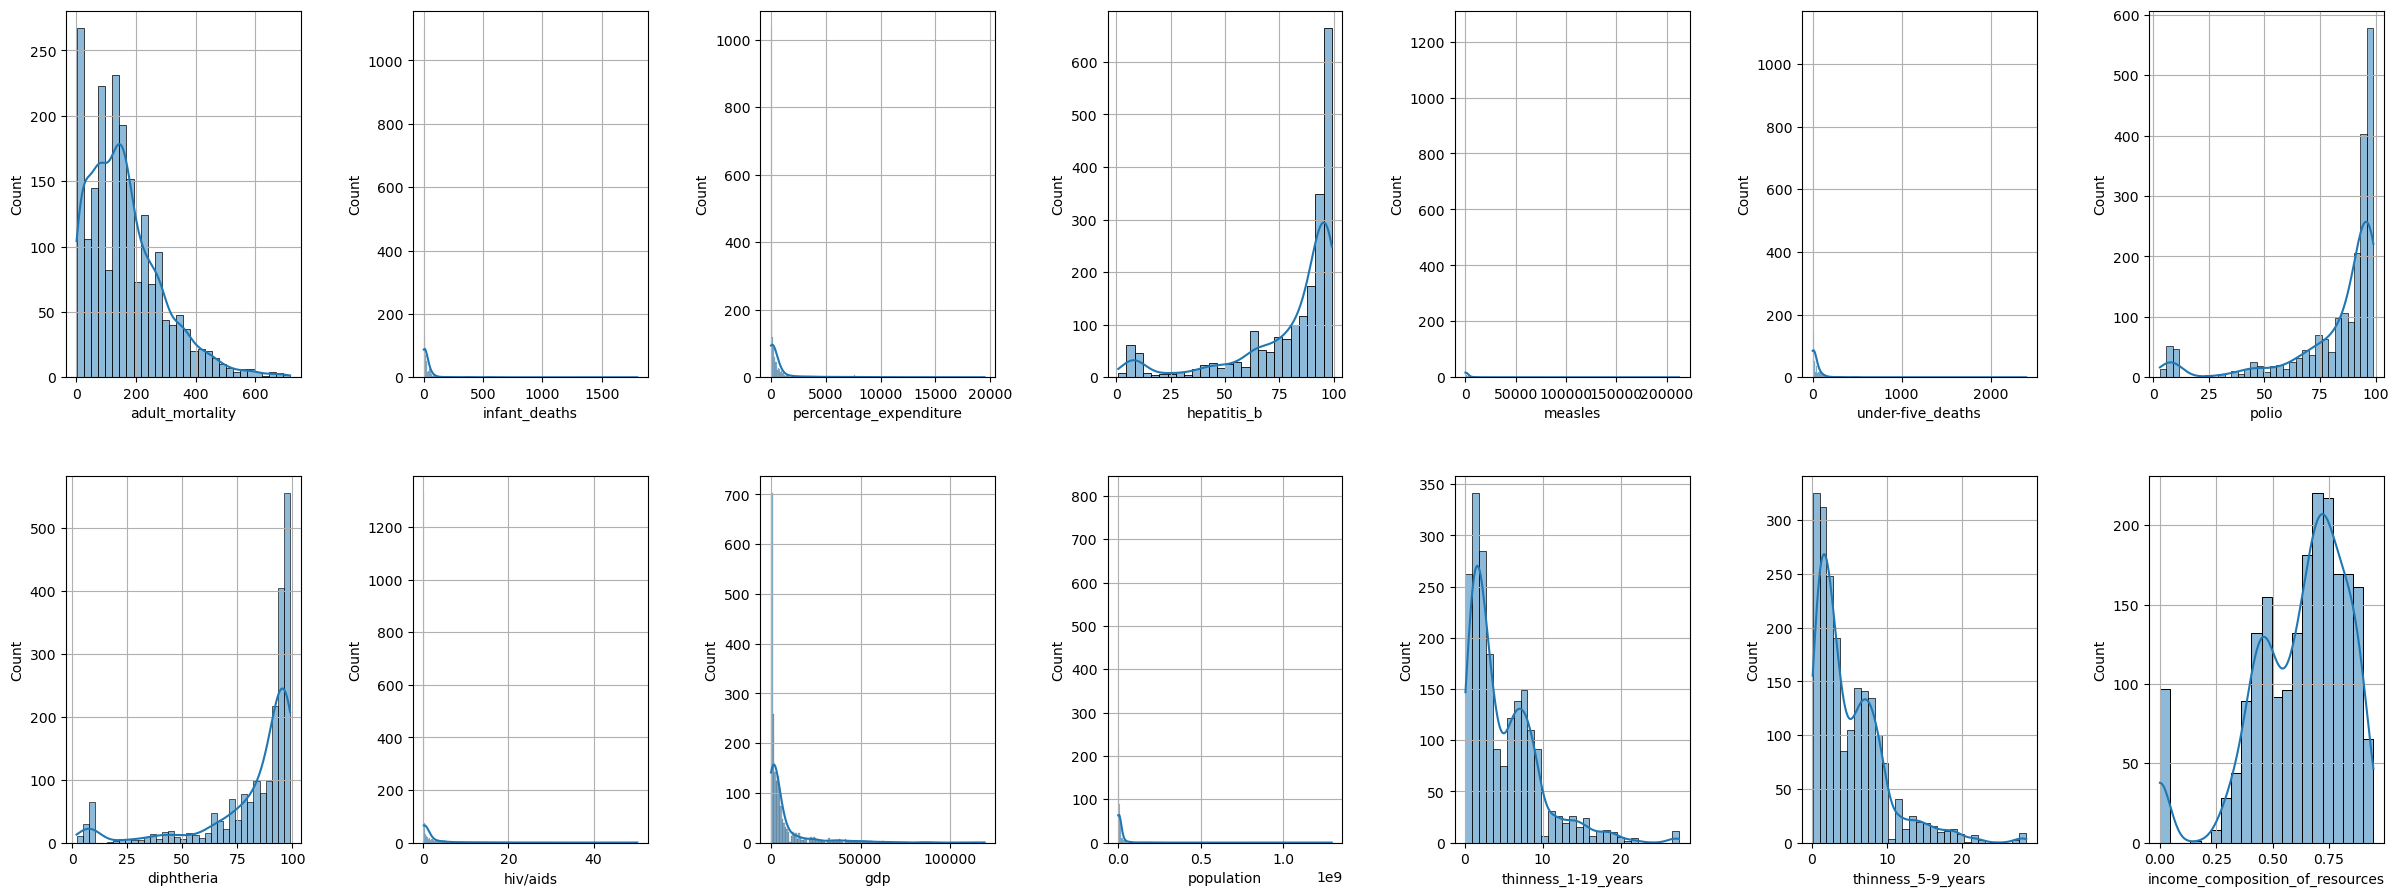

In [420]:
fig, ax = plt.subplots(2,7, figsize=(25,10))
fig.tight_layout(pad=5.)
for i,col in enumerate(skewed_cols):
    row = i // 7
    col_idx = i % 7
    sns.histplot(data=experimental_train_data, x=experimental_train_data[col], ax=ax[row,col_idx], kde=True).grid(True)

For features that are skewed to the right, we can take `log` from them to make them look more normal like distributed. For left skewed data we can use many different transformations (like Box-cox, or taking the feature to the `n` power.) to also make them more normal distributed. We also can see several features with bimodal distribution, we will perform the `RBF` (radial basis function) to calculate the probability of each sample to the modes in each feature.

c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  res

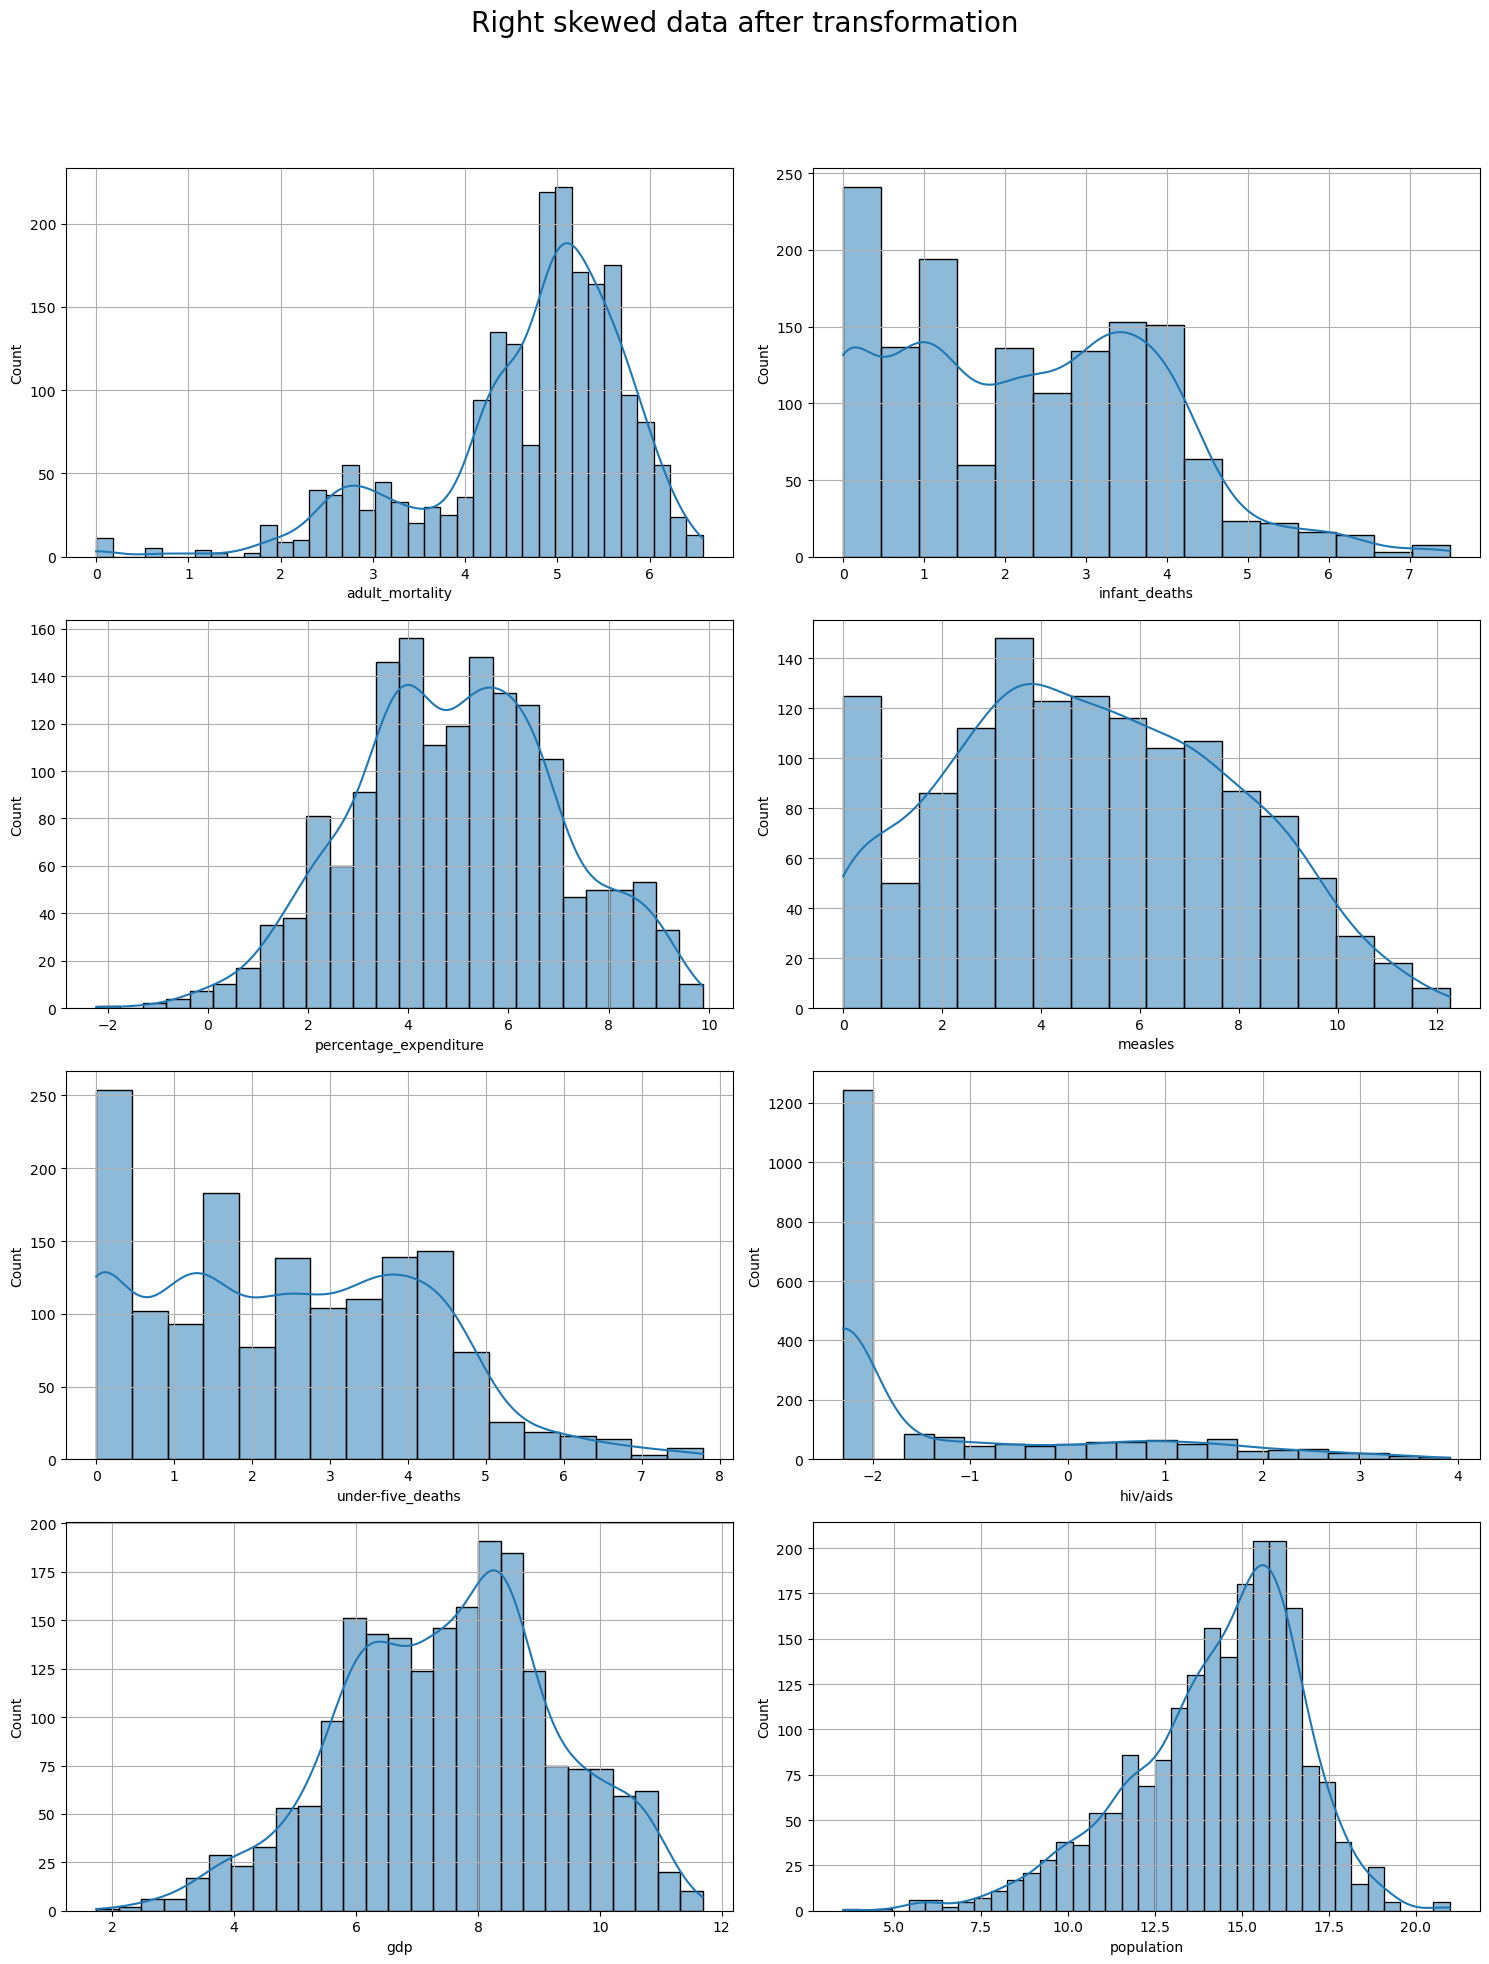

In [421]:
log_skewed_features = skew.index[skew.values > 1].to_list()[:-2] # removing the bimodal features

fig, ax = plt.subplots(4,2, figsize=(15,20))
fig.suptitle("Right skewed data after transformation", fontsize=20)
for i, col in enumerate(log_skewed_features):
    row = i // 2
    col_idx = i % 2
    #data = train_data_status[train_data_status[col]>0]
    sns.histplot(np.log(experimental_train_data[col]), kde=True, ax = ax[row, col_idx]).grid(True)
    experimental_train_data[f"log_{col}"] = np.log(experimental_train_data[col]).replace([np.inf, -np.inf], 0)
plt.tight_layout(rect=[0, 0, 1, 0.93])

Lets see the results of the transformation:

In [422]:
log_trans_features = [col for col in experimental_train_data.columns if 'log_' in col]
print("Skewness before transformation:\n")
print(experimental_train_data[log_skewed_features].skew(),"\n")

print("Skewness after transformation:\n")
print(experimental_train_data[log_trans_features].skew())

Skewness before transformation:

adult_mortality            1.156995
infant_deaths              9.696920
percentage_expenditure     4.799401
measles                    9.842365
under-five_deaths          9.291147
hiv/aids                   5.108115
gdp                        3.423550
population                16.287311
dtype: float64 

Skewness after transformation:

log_adult_mortality          -1.254083
log_infant_deaths             0.755086
log_percentage_expenditure   -0.082032
log_measles                   0.556419
log_under-five_deaths         0.675333
log_hiv/aids                  1.255557
log_gdp                      -0.162350
log_population               -0.760133
dtype: float64


As we see taking `log` from right skewed data, can significantly lower the skewness in our data and (probably) increase the correlation with target variable (we will check it a little bit later). Now - lets focus on left skewed data.

c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(0.0, 1.0, 0.0, 1.0)

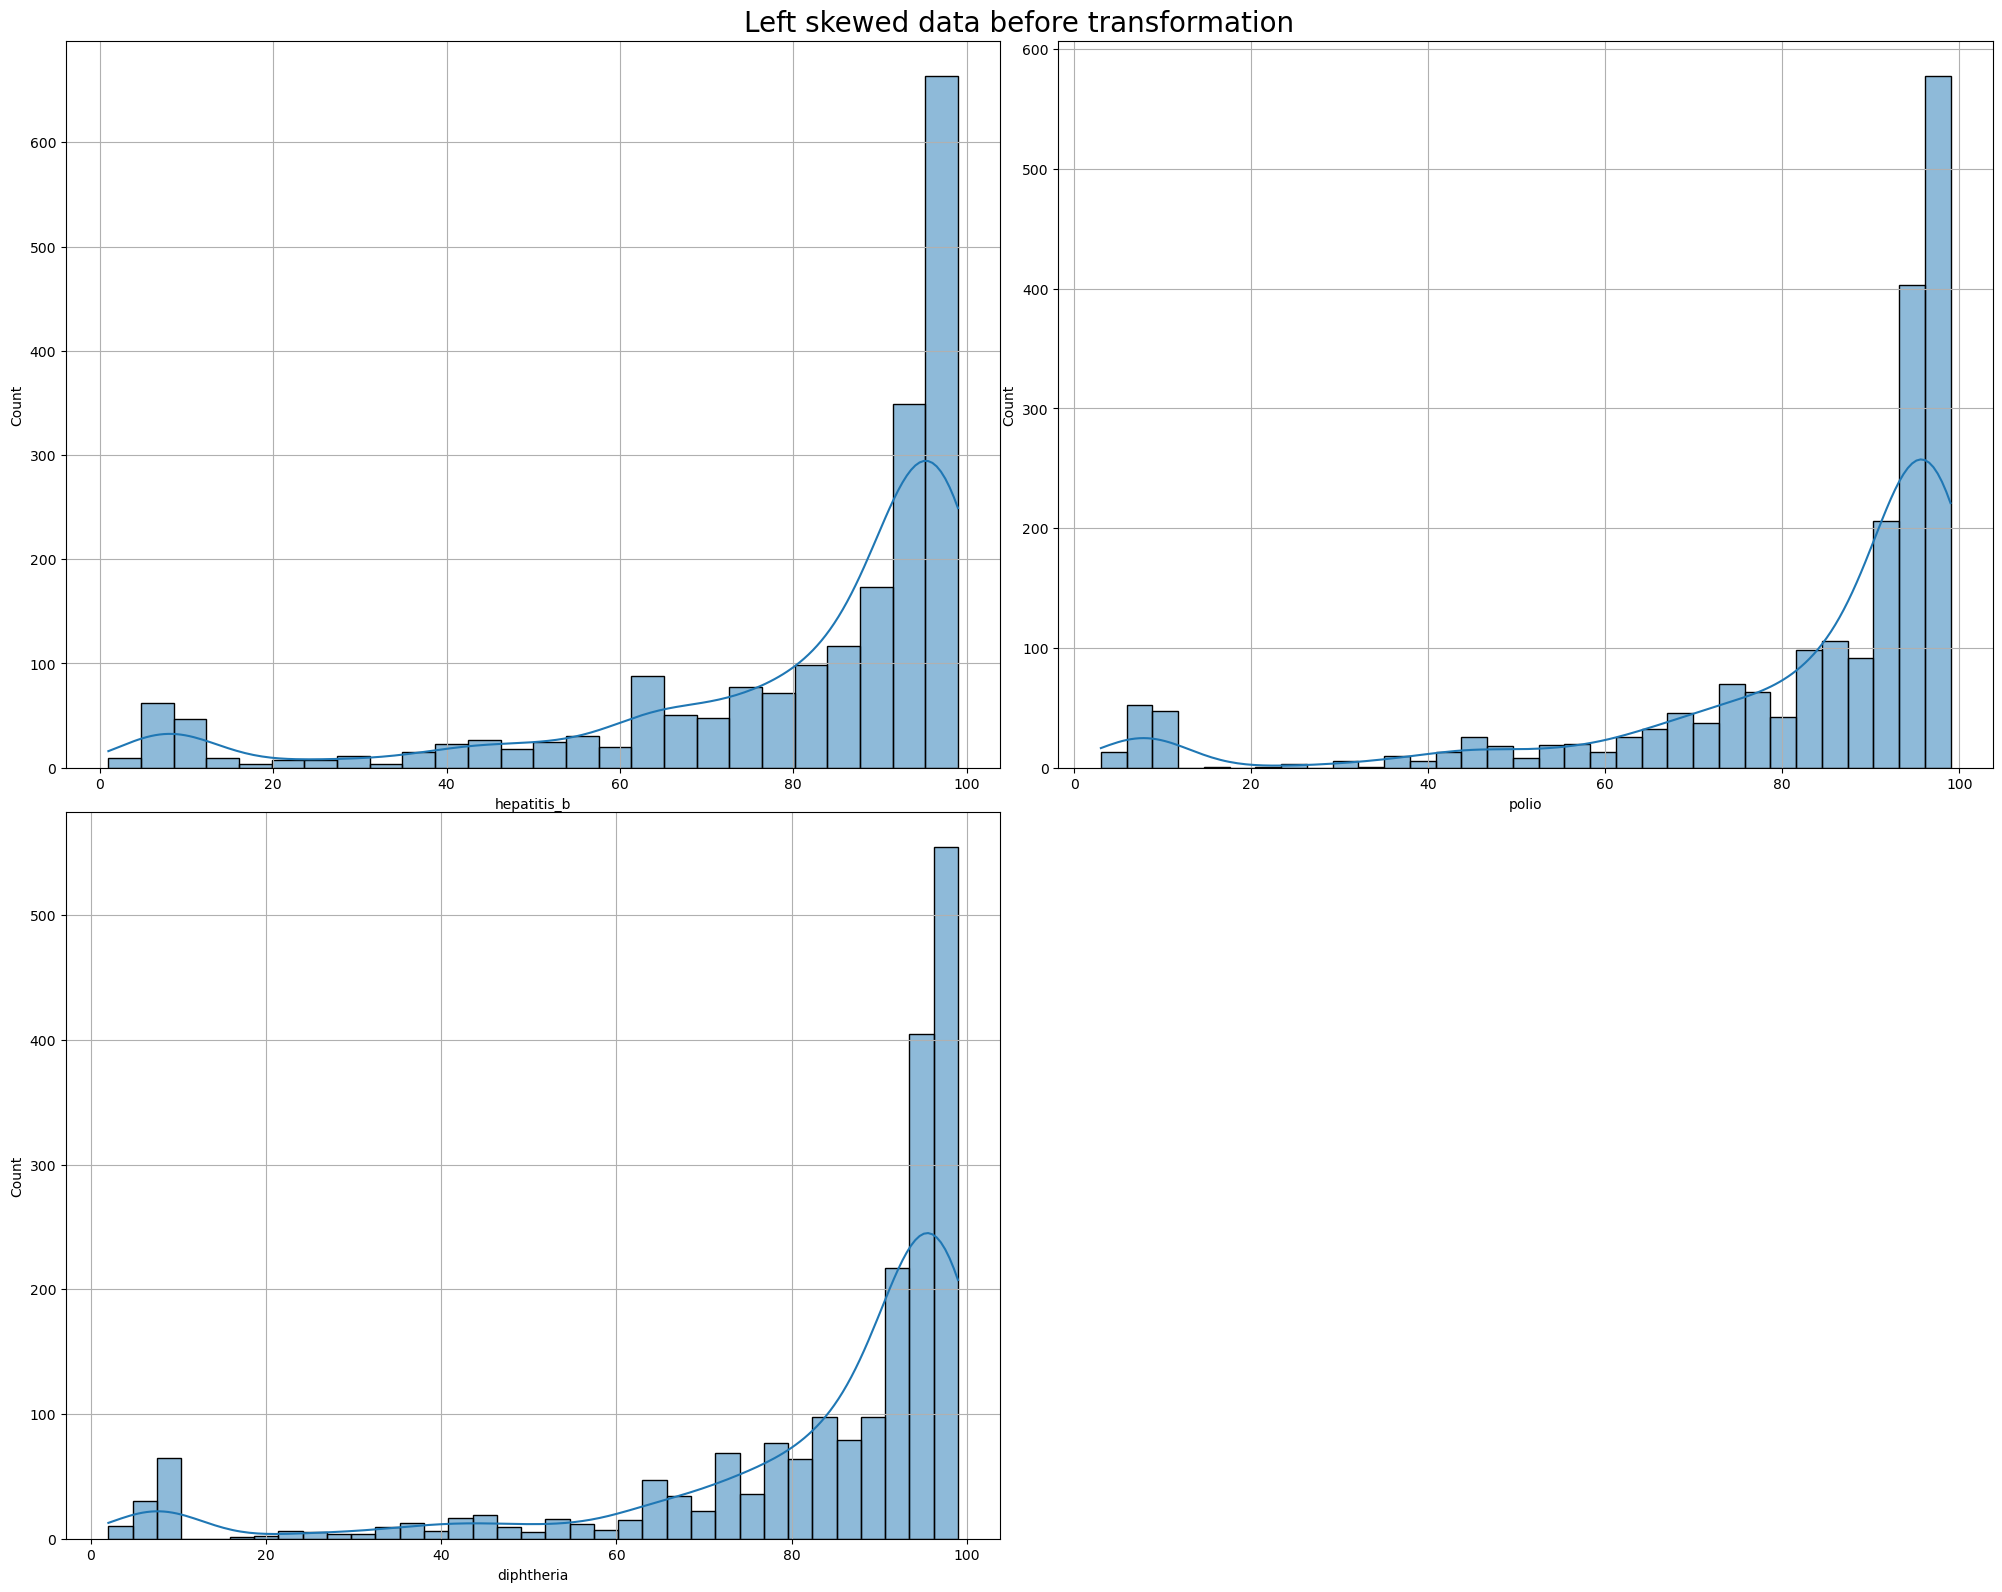

In [423]:
left_skewed_features = skew.index[skew.values < -1].to_list()[:-1] #Removing the bimodal feature

fig, ax = plt.subplots(2,2,figsize=(20,16))
fig.suptitle("Left skewed data before transformation", fontsize=20, );
fig.tight_layout()
for i, col in enumerate(left_skewed_features):
    row = i // 2
    col_idx = i % 2
    sns.histplot(experimental_train_data[col], kde=True, ax=ax[row, col_idx]).grid(True)
ax[1,1].axis('off')

c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


(0.0, 1.0, 0.0, 1.0)

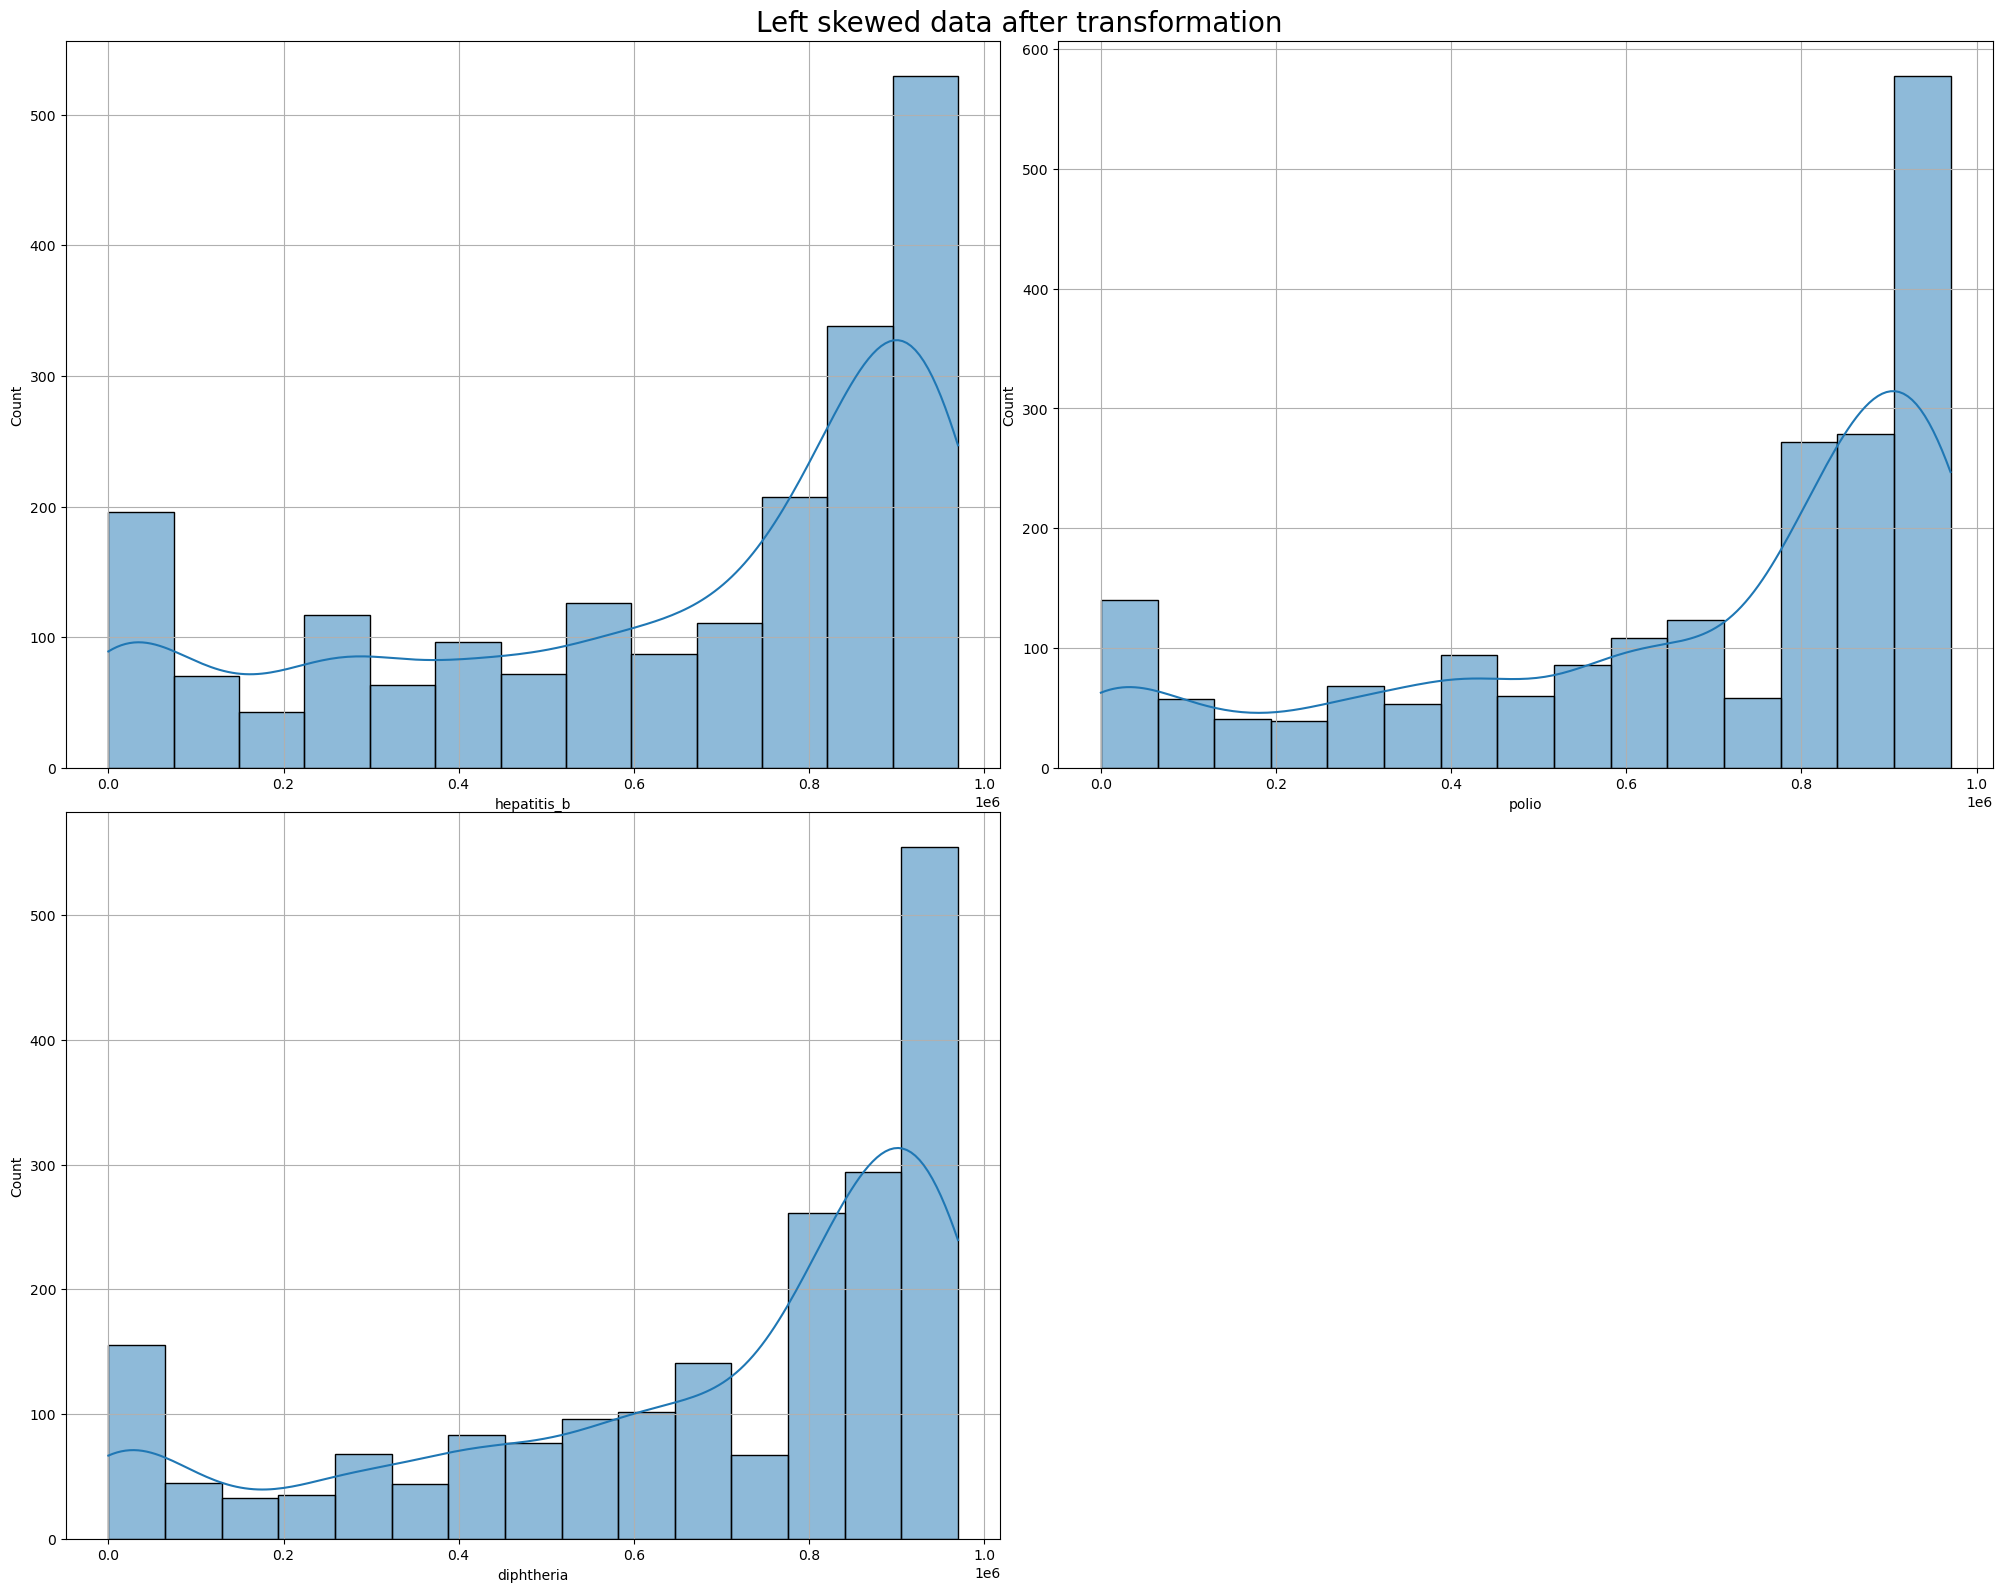

In [424]:
fig, ax = plt.subplots(2,2,figsize=(20,16))
fig.suptitle("Left skewed data after transformation", fontsize=20);
fig.tight_layout()
for i, col in enumerate(box_skewed_features):
    row = i // 2
    col_idx = i % 2
    sns.histplot(experimental_train_data[col]**3, ax=ax[row, col_idx], kde=True).grid(True) #Taking the feature to the third power.
    experimental_train_data[f"pow3_{col}"] = experimental_train_data[col]**3
ax[1,1].axis('off')

In [425]:
power_cols = [col for col in experimental_train_data.columns if 'pow3' in col]
print("Skewness before transformation: \n")
print(experimental_train_data[left_skewed_features].skew(), "\n")
print("Skewness after transformation: \n")
print(experimental_train_data[power_cols].skew())

Skewness before transformation: 

hepatitis_b   -1.761510
polio         -2.099548
diphtheria    -2.108193
dtype: float64 

Skewness after transformation: 

pow3_hepatitis_b   -0.742890
pow3_polio         -0.954127
pow3_diphtheria    -0.986209
dtype: float64


Taking the features to the power of 3 seems like a good idea to reduce the skewness in our data, however it's only working with left skewed data. Now let's focus on the binominal features. We will build a custom transformer that will measure the probability of belonging to a particular cluster defined by `KMeans` algorithm.

c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-pack

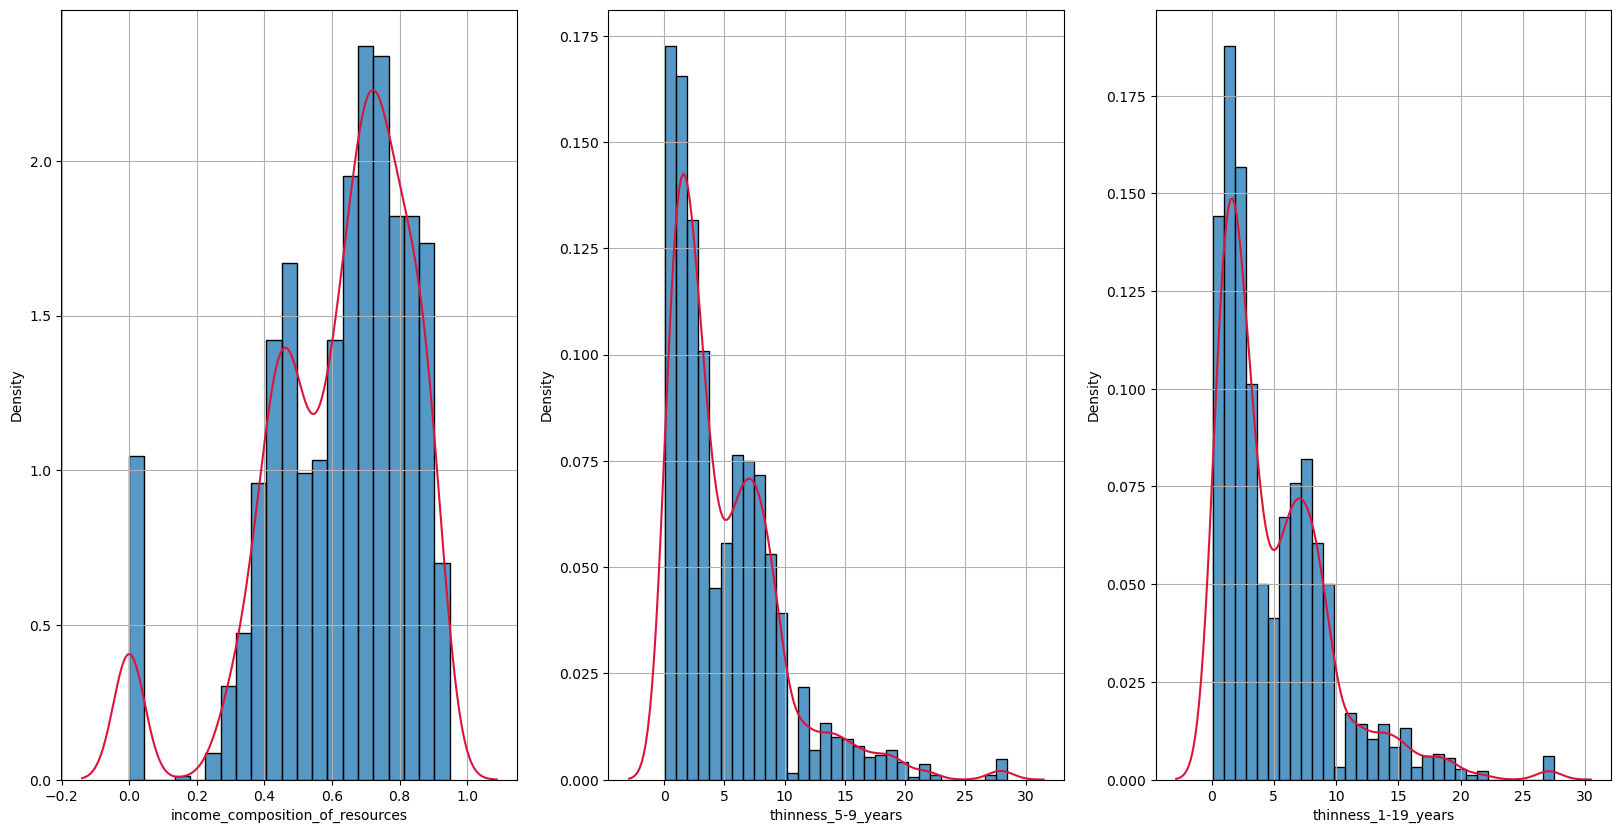

In [426]:
binom_features = ['income_composition_of_resources','thinness_5-9_years','thinness_1-19_years']
fig, ax = plt.subplots(1,3, figsize=(20,10))
for i, col in enumerate(binom_features):
    sns.histplot(experimental_train_data[col], ax=ax[i], kde=False, stat='density')
    sns.kdeplot(experimental_train_data[col], ax=ax[i], color='crimson')
    ax[i].grid(True)

In [427]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=3, gamma = 0.1, random_state = None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
        
    def fit(self, X, y=None, sample_weight = None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma = self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Proba_{i}_cluster" for i in range (self.n_clusters)]



In [428]:
CS = ClusterSimilarity(n_clusters=3)
preds = CS.fit_transform(experimental_train_data[['thinness_5-9_years','thinness_1-19_years']]).round(3)
CS_data = pd.DataFrame(
    preds,
    columns=CS.get_feature_names_out()
)
CS_data


c:\Users\gnaporowski\AppData\Local\anaconda3\envs\moje_srodowisko\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


,Proba_0_cluster,Proba_1_cluster,Proba_2_cluster
0,0.001,0.979,0.0
1,0.752,0.028,0.0
2,0.016,0.858,0.0
3,0.000,0.722,0.0
4,0.318,0.160,0.0
...,...,...,...
2051,0.000,0.872,0.0
2052,0.787,0.024,0.0
2053,0.769,0.026,0.0
2054,0.748,0.000,0.0


In case of `income_composition_of_resources`, we will leave the feature as it is. Our cluster method will probably not work, because there's not much fluctuaion in the data, so cluster centers will be close to eachother, and by that our method with calculating probability will assign high probability to each cluster:

In [429]:
experimental_train_data = experimental_train_data.join(CS_data)
experimental_train_data.head(5)

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,log_under-five_deaths,log_hiv/aids,log_gdp,log_population,pow3_hepatitis_b,pow3_polio,pow3_diphtheria,Proba_0_cluster,Proba_1_cluster,Proba_2_cluster
0,Liberia,2008,Developing,58.6,281.0,10,3.88,40.033441,64.0,1,...,2.639057,0.875469,5.449395,15.113791,262144.0,493039.0,421875.0,0.001,0.979,0.0
1,Lithuania,2004,Developed,71.6,24.0,0,12.10,76.361877,94.0,1,...,0.000000,-2.302585,6.517623,12.730135,830584.0,729.0,830584.0,0.752,0.028,0.0
2,Morocco,2004,Developing,72.0,142.0,23,0.56,100.363832,95.0,6399,...,3.295837,-2.302585,7.574975,14.972167,857375.0,912673.0,912673.0,0.016,0.858,0.0
3,Guinea,2008,Developing,56.8,33.0,30,0.21,19.685103,57.0,89,...,3.850148,0.832909,6.080955,14.095520,185193.0,205379.0,216.0,0.000,0.722,0.0
4,Saint Lucia,2011,Developing,74.6,143.0,0,10.43,0.000000,99.0,0,...,0.000000,-2.302585,8.906639,16.670436,970299.0,970299.0,970299.0,0.318,0.160,0.0
